# Networks Analysis

In [53]:
import pypsa
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import os

### Choose the networks to analyse

In [4]:
capacity_scenarios = ["germany_scenario1", "germany_scenario2"]

In [37]:
home = "/home/lucakristin/Desktop/my_pypsa"
cluster = "450"
folder = "germany_scenario2_"

### Create folder and paths

In [38]:
# Create analysis output directory and logging file
analysis_dir = f"{home}/pypsa-eur/analysis/{folder}"
os.makedirs(analysis_dir, exist_ok=True)
log_file = os.path.join(analysis_dir, "summary.txt")

# Initialize/clear the log file with header
with open(log_file, "w") as _f:
    _f.write(f"Networks comparison summary\nGenerated: {datetime.now().isoformat()}\n\n")

def log_print(*args, sep=' ', end='\n', also_print=True):
    """Helper to print and append to the summary log"""
    s = sep.join(str(a) for a in args) + end
    if also_print:
        print(*args, sep=sep, end=end)
    with open(log_file, 'a') as _f:
        _f.write(s)

def save_fig(fig, name, dpi=150):
    """Helper to save a matplotlib figure into the analysis folder"""
    fname = os.path.join(analysis_dir, name)
    fig.savefig(fname, bbox_inches='tight', dpi=dpi)
    log_print(f"Saved figure: {fname}")

### Set paths

In [39]:
# Paths to the three networks
network_paths = {
    "windy": f"{home}/pypsa-eur/results/{folder}windy/networks/base_s_{cluster}_elec_.nc",
    "notwindy": f"{home}/pypsa-eur/results/{folder}notwindy/networks/base_s_{cluster}_elec_.nc",
    "windvariability": f"{home}/pypsa-eur/results/{folder}windvariability/networks/base_s_{cluster}_elec_.nc"
}

# Load the networks
networks = {name: pypsa.Network(path) for name, path in network_paths.items()}
n1 = networks["windy"]
n2 = networks["notwindy"]
n3 = networks["windvariability"]

n1.name = "Windy"
n2.name = "Not Windy"
n3.name = "Wind Variability"

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


### Check

In [40]:
# --- Verification Step: Check if lines were extended ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines:
        if n.lines.s_nom.equals(n.lines.s_nom_opt):
            log_print(f"Verification PASSED for '{name}' network: Line capacities were not extended (s_nom equals s_nom_opt).")
        else:
            diff_count = (n.lines.s_nom != n.lines.s_nom_opt).sum()
            log_print(f"Verification FAILED for '{name}' network: {diff_count} lines have different s_nom and s_nom_opt.")
    else:
        log_print(f"Verification NOTE for '{name}' network: No 's_nom_opt' column found; assuming lines were not extendable.")

Verification PASSED for 'windy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'notwindy' network: Line capacities were not extended (s_nom equals s_nom_opt).
Verification PASSED for 'windvariability' network: Line capacities were not extended (s_nom equals s_nom_opt).


In [41]:
# --- Fix Step: If verification fails, disable line extension on the base network ---
for name, n in networks.items():
    if "s_nom_opt" in n.lines and not n.lines.s_nom.equals(n.lines.s_nom_opt):
        print(f"Fixing base network for '{name}'...")
        
        # Construct the path to the original base network in the 'resources' directory
        base_network_path = f"{home}/pypsa-eur/resources/{folder}{name}/networks/base_s_{cluster}_elec_.nc"
        
        # Check if the file exists before trying to modify it
        if not os.path.exists(base_network_path):
            print(f"ERROR: Base network file not found at {base_network_path}. Skipping fix.")
            continue

        # Load the original base network
        base_n = pypsa.Network(base_network_path)
        
        # Set s_nom_extendable to False
        for component in base_n.iterate_components(["Line", "Link"]):
            if "s_nom_extendable" in component.df.columns:
                component.df["s_nom_extendable"] = False
            
        # Save the corrected network back to its original location
        base_n.export_to_netcdf(base_network_path)
        print(f"'{name}' base network at {base_network_path} has been updated to disable line extensions.")
        print("Warning: Remember to rerun solve to apply the changes!")
    else:
        print(f"No fix needed for '{name}' network; line extension verification passed.")

No fix needed for 'windy' network; line extension verification passed.
No fix needed for 'notwindy' network; line extension verification passed.
No fix needed for 'windvariability' network; line extension verification passed.


### Capacities

In [42]:
def get_capacity_percentages(network):
    """Calculates the capacity share by carrier for a given network across generators and storage units."""
    generator_capacity = network.generators.groupby("carrier").p_nom.sum()
    storage_capacity = network.storage_units.groupby("carrier").p_nom.sum() if not network.storage_units.empty else pd.Series(dtype=float)
    carrier_capacity = pd.concat([generator_capacity, storage_capacity]).groupby(level=0).sum()
    carrier_capacity_pct = 100 * carrier_capacity / carrier_capacity.sum()
    return carrier_capacity_pct.round(2)


def load_networks(home, base_folder, cluster, wind_opt, scenario_name):
    """Loads the base and scenario networks."""
    base_config_name = f"{base_folder}{wind_opt}"
    scenario_config_name = f"{scenario_name}_{wind_opt}"
    
    base_network_path_unsolved = f"{home}/pypsa-eur/results/{base_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_base_unsolved = pypsa.Network(base_network_path_unsolved)
    
    scenario_network_path_unsolved = f"{home}/pypsa-eur/resources/{scenario_config_name}/networks/base_s_{cluster}_elec_.nc"
    n_scenario_unsolved = pypsa.Network(scenario_network_path_unsolved)
    
    return n_base_unsolved, n_scenario_unsolved, base_config_name, scenario_config_name

def plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name):
    """Plots the initial installed capacity comparison on a given axes across generators and storage units."""
    p_nom_base = pd.concat([
        n_base.generators.groupby("carrier").p_nom.sum(),
        n_base.storage_units.groupby("carrier").p_nom.sum() if not n_base.storage_units.empty else pd.Series(dtype=float),
    ]).groupby(level=0).sum()
    p_nom_scenario = pd.concat([
        n_scenario.generators.groupby("carrier").p_nom.sum(),
        n_scenario.storage_units.groupby("carrier").p_nom.sum() if not n_scenario.storage_units.empty else pd.Series(dtype=float),
    ]).groupby(level=0).sum()

    df = pd.DataFrame({
        "Base": p_nom_base,
        "Scenario": p_nom_scenario
    }).dropna()

    df.plot(kind="bar", ax=ax, rot=45)
    ax.set_ylabel("Installed Capacity [MW]")
    ax.set_title(f"Base: {base_name} vs Scenario: {scenario_name}")
    ax.grid(True)

    return df

INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)


Capacity comparison for germany_scenario1_notwindy:
                       Base      Scenario
carrier                                  
CCGT           18465.748665   6856.780411
OCGT            2308.218583   2285.593470
PHS             7361.720000   7361.720000
biomass        11541.092916   7702.449995
coal            4616.437166   2285.593470
geothermal        23.082186     22.855935
hydro            402.238150    402.238150
lignite         4616.437166    447.976320
offwind-ac     23082.185832  41140.682466
offwind-dc         0.000000      0.000000
offwind-float      0.000000      0.000000
oil             2308.218583   2285.593470
onwind         87712.306160  86852.551872
ror             2308.218583   2454.727387
solar          62321.901745  57139.836758
solar-hsat         0.000000      0.000000
waste           4616.437166   3085.551185



INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks
INFO:pypsa.network.io:New version 1.2.0 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units, stores, sub_networks


Capacity comparison for germany_scenario2_notwindy:
                       Base      Scenario
carrier                                  
CCGT           18465.748665  18465.748665
OCGT            2308.218583   2308.218583
PHS             7361.720000   7361.720000
biomass        11541.092916  11541.092916
coal            4616.437166   4616.437166
geothermal        23.082186     23.082186
hydro            402.238150    402.238150
lignite         4616.437166   4616.437166
offwind-ac     23082.185832  23082.185832
offwind-dc         0.000000      0.000000
offwind-float      0.000000      0.000000
oil             2308.218583   2308.218583
onwind         87712.306160  87712.306160
ror             2308.218583   2308.218583
solar          62321.901745  62321.901745
solar-hsat         0.000000      0.000000
waste           4616.437166   4616.437166

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/01_capacity_comparison.png


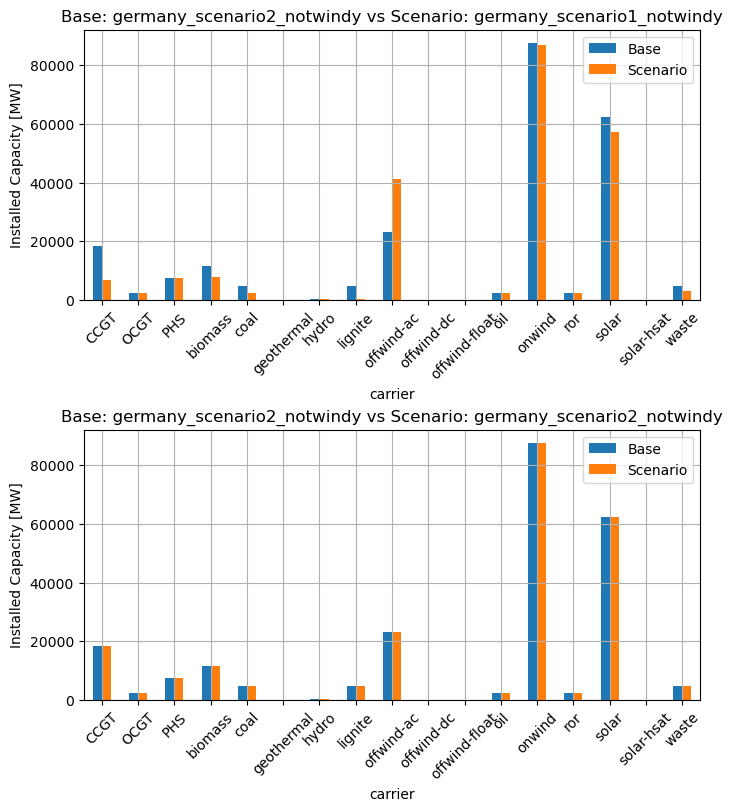

In [43]:
# Create a figure with subplots
num_scenarios = len(capacity_scenarios)
fig, axes = plt.subplots(num_scenarios, 1, figsize=(7, 4 * num_scenarios), constrained_layout=True)

wind_opt = "notwindy"  # or "notwindy" or "windvariability"
for j, scenario_name in enumerate(capacity_scenarios):
    ax = axes[j]
    n_base, n_scenario, base_name, scenario_name_full = load_networks(home, folder, cluster, wind_opt, scenario_name)
    capacities = plot_capacity_comparison(ax, n_base, n_scenario, base_name, scenario_name_full)

    # Get percentages for both scenarios
    base_percentages = get_capacity_percentages(n_base)
    scenario_percentages = get_capacity_percentages(n_scenario)

    # Combine into a single DataFrame for side-by-side comparison
    comparison_df = pd.DataFrame({
        f"Base ({base_name})": base_percentages,
        f"Scenario ({scenario_name_full})": scenario_percentages
    })

    # Sort by the base percentages in descending order
    comparison_df = comparison_df.sort_values(by=f"Base ({base_name})", ascending=False)

    with pd.option_context('display.max_rows', None, 'display.max_columns', None):
        log_print(f"Capacity comparison for {scenario_name_full}:")
        log_print(capacities.to_string())
        log_print("")

save_fig(fig, "01_capacity_comparison.png")

In [44]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    for dfname in ["buses","lines","generators","loads","links","storage_units","stores"]:
        if hasattr(n, dfname):
            log_print(f"  {dfname}: {len(getattr(n, dfname))}")


=== Network Statistics ===

Network: Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Not Windy
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900

Network: Wind Variability
  buses: 1350
  lines: 628
  generators: 4592
  loads: 450
  links: 1800
  storage_units: 60
  stores: 900


### Grid Congestion and Curtailment

##### Marginal Prices

Plotting 'Windy' network at time 2025-10-26 18:00:00 with peak marginal price 54.03 €/MWh
Minimum marginal price across all buses at peak time: -27.33 €/MWh

Windy Marginal Price Statistics:
count    1350.000000
mean       13.405300
std        12.168182
min       -27.334435
25%         0.077911
50%        12.787866
75%        18.531416
max        54.031247

Plotting 'Not Windy' network at time 2025-04-08 05:00:00 with peak marginal price 125.50 €/MWh
Minimum marginal price across all buses at peak time: -17.58 €/MWh

Not Windy Marginal Price Statistics:
count    1350.000000
mean       65.278138
std        15.463935
min       -17.581704
25%        57.597955
50%        60.614304
75%        65.713705
max       125.500630

Plotting 'Wind Variability' network at time 2025-10-06 12:00:00 with peak marginal price 144.22 €/MWh
Minimum marginal price across all buses at peak time: -27.62 €/MWh

Wind Variability Marginal Price Statistics:
count    1350.000000
mean       42.915295
std        37.7

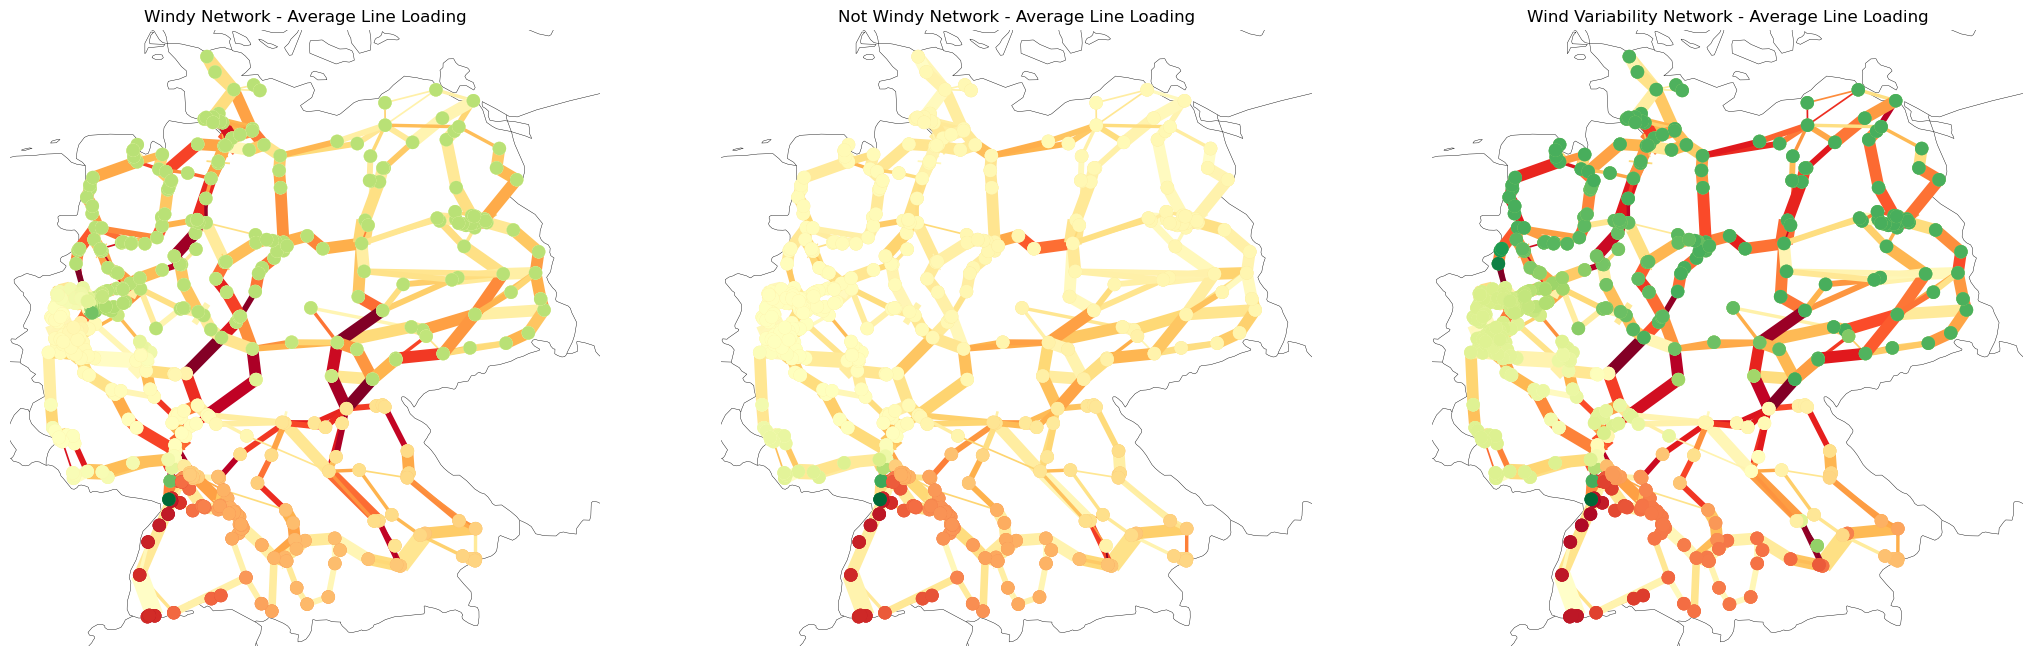

In [45]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_congestion(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    
    # Find the time with the highest overall marginal price
    peak_price_time = n.buses_t.marginal_price.max(axis=1).idxmax()
    peak_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Plotting '{n.name}' network at time {peak_price_time} with peak marginal price {peak_prices.max():.2f} €/MWh")

    min_prices = n.buses_t.marginal_price.loc[peak_price_time]
    log_print(f"Minimum marginal price across all buses at peak time: {min_prices.min():.2f} €/MWh")
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=0.01,
        bus_colors=peak_prices,
        bus_cmap='RdYlGn_r',
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

    return peak_prices

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    peak_prices = plot_network_congestion(n, axes[i], n.name + " Network - Average Line Loading")
    log_print(f"\n{n.name} Marginal Price Statistics:")
    log_print(peak_prices.describe().to_string())
    log_print("")
    i += 1

save_fig(fig, "02_marginal_prices.png")

### Load shedding

 Network: Windy
  Average loading across all lines: 23.56%
  Max average loading: 69.92%
  Lines with >60% avg loading: 30
  Lines with >70% avg loading: 0

 Network: Not Windy
  Average loading across all lines: 13.10%
  Max average loading: 69.97%
  Lines with >60% avg loading: 3
  Lines with >70% avg loading: 0

 Network: Wind Variability
  Average loading across all lines: 26.19%
  Max average loading: 69.97%
  Lines with >60% avg loading: 28
  Lines with >70% avg loading: 0

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/03_load_shedding.png


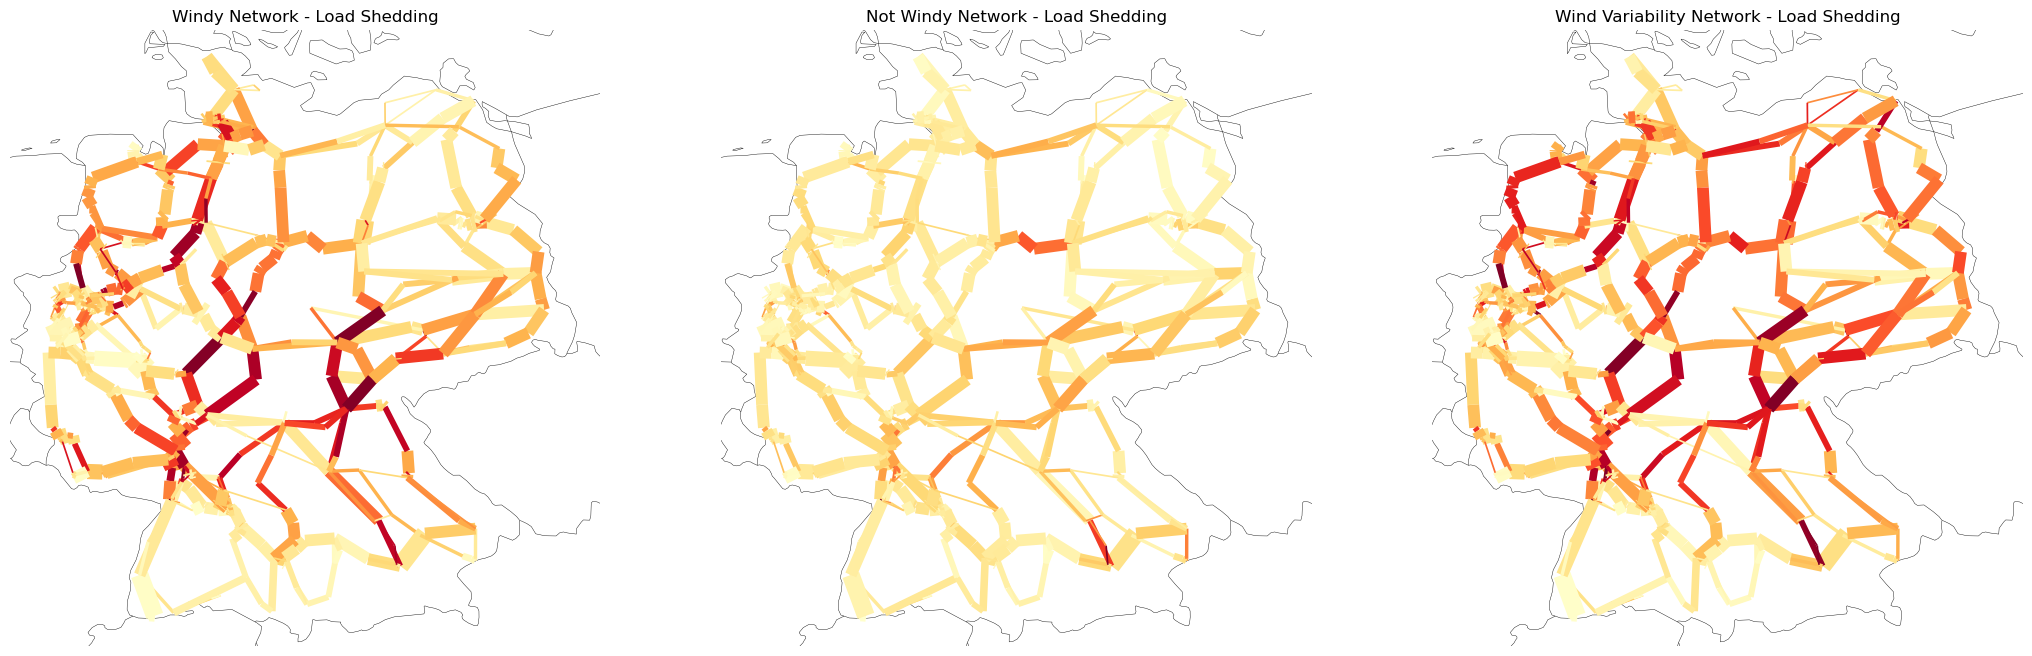

In [46]:
# --- Create enhanced visualization ---
fig, axes = plt.subplots(1, 3, figsize=(26, 8), subplot_kw={"projection": ccrs.EqualEarth()})

# --- Helper Function to Plot Network with Average Loading ---
def plot_network_load(n, ax, title):
    avg_loading_n = (n.lines_t.p0.abs() / n.lines.s_nom).mean()
    load_mask = n.generators.carrier.str.contains("load", case=False, na=False)
    shed_gens = n.generators.index[load_mask]

    if len(shed_gens) == 0:
        log_print("No generator carrier containing 'load' found. Plot will show zeros.")
        shed_by_bus_time = pd.DataFrame(
            0.0, index=n.snapshots, columns=n.buses.index
        )
    else:
        # Time series of unmet load aggregated by bus [MW].
        shed_by_bus_time = (
            n.generators_t.p[shed_gens]
            .T.groupby(n.generators.loc[shed_gens, "bus"])
            .sum()
            .T
            .reindex(columns=n.buses.index, fill_value=0.0)
        )

    # Pick the snapshot with the highest system-wide unmet load.
    total_shed = shed_by_bus_time.sum(axis=1)
    worst_shed_snapshot = total_shed.idxmax()
    unmet_load_at_snapshot = shed_by_bus_time.loc[worst_shed_snapshot]
    
    n.plot(
        ax=ax,
        geomap=True,
        title=title,
        bus_sizes=unmet_load_at_snapshot/5000,
        bus_alpha=0.5,
        bus_cmap="YlOrRd",
        line_colors=avg_loading_n,
        line_cmap="YlOrRd",
        line_width=n.lines.s_nom / 400,
        link_width=n.links.p_nom / 400 if not n.links.empty else 0,
    )

    return avg_loading_n

# Plot Average Loading Over All Snapshots for each network
i = 0
for n in networks.values():
    avg_loading = plot_network_load(n, axes[i], n.name + " Network - Load Shedding")
    log_print("=" * 70)
    log_print(f" Network: {n.name}")
    log_print(f"  Average loading across all lines: {avg_loading.mean():.2%}")
    log_print(f"  Max average loading: {avg_loading.max():.2%}")
    log_print(f"  Lines with >60% avg loading: {(avg_loading > 0.6).sum()}")
    log_print(f"  Lines with >70% avg loading: {(avg_loading > 0.7).sum()}")
    log_print("=" * 70)
    log_print("")
    i += 1

save_fig(fig, "03_load_shedding.png")

##### Offshore Wind Curtailment

Network: Windy
offwind-ac capacity MW: 23082.185831516847
Total available (MWh): 488403.9141732764
Total dispatched (MWh): 25270.397089523787
Total curtailed (MWh): 463133.51708375255
Curtailed fraction: 0.9482592248829554

Network: Not Windy
offwind-ac capacity MW: 23082.185831516847
Total available (MWh): 17195.486304704522
Total dispatched (MWh): 17195.480587652666
Total curtailed (MWh): 0.005717051853937782
Curtailed fraction: 3.324739848953066e-07

Network: Wind Variability
offwind-ac capacity MW: 23082.185831516847
Total available (MWh): 358871.2492112648
Total dispatched (MWh): 116303.15357082486
Total curtailed (MWh): 242568.09564043995
Curtailed fraction: 0.675919556591846

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/04_offwind_curtailment.png


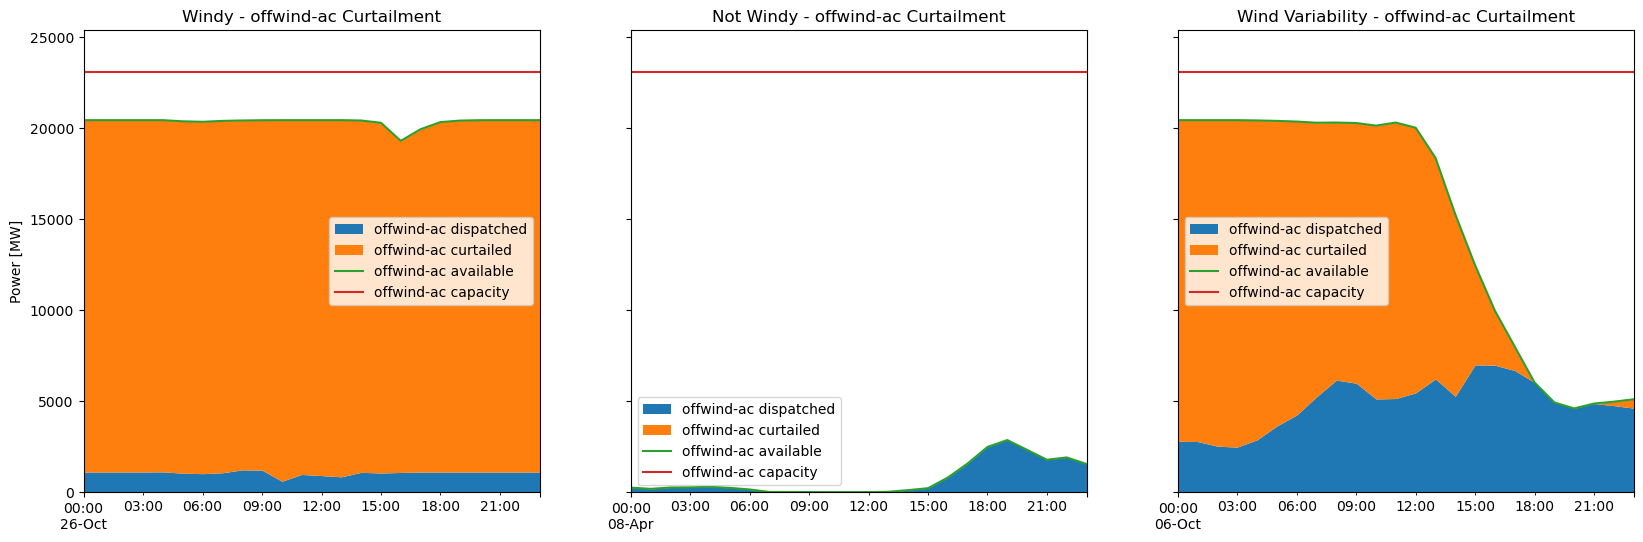

In [47]:
def plot_curtailment(n, carrier, ax):
    p_available_by_carrier = (
        n.generators_t.p_max_pu.multiply(n.generators.p_nom).T.groupby(n.generators.carrier).sum().T
    )
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_curtailed_by_carrier = p_available_by_carrier - p_by_carrier

    # Correct for any minor negative values from floating point inaccuracies.
    p_curtailed_by_carrier[p_curtailed_by_carrier < 0] = 0

    capacity = n.generators.groupby("carrier")["p_nom"].sum().at[carrier]

    p_df = pd.DataFrame(
        {
            carrier + " available": p_available_by_carrier[carrier],
            carrier + " dispatched": p_by_carrier[carrier],
            carrier + " curtailed": p_curtailed_by_carrier[carrier],
        }
    )

    p_df[carrier + " capacity"] = capacity
    p_df[[carrier + " dispatched", carrier + " curtailed"]].plot(kind="area", ax=ax, lw=0)
    p_df[[carrier + " available", carrier + " capacity"]].plot(ax=ax)

    ax.set_xlabel("")
    ax.set_ylabel("Power [MW]")
    ax.set_ylim([0, p_df[carrier + " capacity"].max() * 1.1 if hasattr(p_df[carrier + " capacity"], "max") else None])
    ax.set_title(f"{n.name} - {carrier} Curtailment")

    p_available = n.generators_t.p_max_pu.multiply(n.generators.p_nom)
    p_av_by = p_available.T.groupby(n.generators.carrier).sum().T
    p_disp_by = n.generators_t.p.T.groupby(n.generators.carrier).sum().T
    p_cur = (p_av_by - p_disp_by).clip(lower=0)

    tot_av = p_av_by[carrier].sum()
    tot_disp = p_disp_by[carrier].sum()
    tot_cur = p_cur[carrier].sum()
    
    log_print("=" * 70)
    log_print(f"Network: {n.name}")
    log_print(f"{carrier} capacity MW: {n.generators.groupby('carrier')['p_nom'].sum().get(carrier)}")
    log_print(f"Total available (MWh): {tot_av}")
    log_print(f"Total dispatched (MWh): {tot_disp}")
    log_print(f"Total curtailed (MWh): {tot_cur}")
    log_print(f"Curtailed fraction: {tot_cur / tot_av if tot_av else float('nan')}")
    log_print("=" * 70)
    log_print("")

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "offwind-ac", axes[0])
plot_curtailment(n2, "offwind-ac", axes[1])
plot_curtailment(n3, "offwind-ac", axes[2])

save_fig(fig, "04_offwind_curtailment.png")

Network: Windy
onwind capacity MW: 87712.306159764
Total available (MWh): 1818996.7286195117
Total dispatched (MWh): 1050758.1017999873
Total curtailed (MWh): 768238.6268195246
Curtailed fraction: 0.42234195077555897

Network: Not Windy
onwind capacity MW: 87712.306159764
Total available (MWh): 59129.559223432414
Total dispatched (MWh): 58894.74165780281
Total curtailed (MWh): 234.81756562960462
Curtailed fraction: 0.0039712382218562

Network: Wind Variability
onwind capacity MW: 87712.306159764
Total available (MWh): 962656.1658912017
Total dispatched (MWh): 761402.774395294
Total curtailed (MWh): 201253.39149590774
Curtailed fraction: 0.20906051259703162

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/05_onwind_curtailment.png


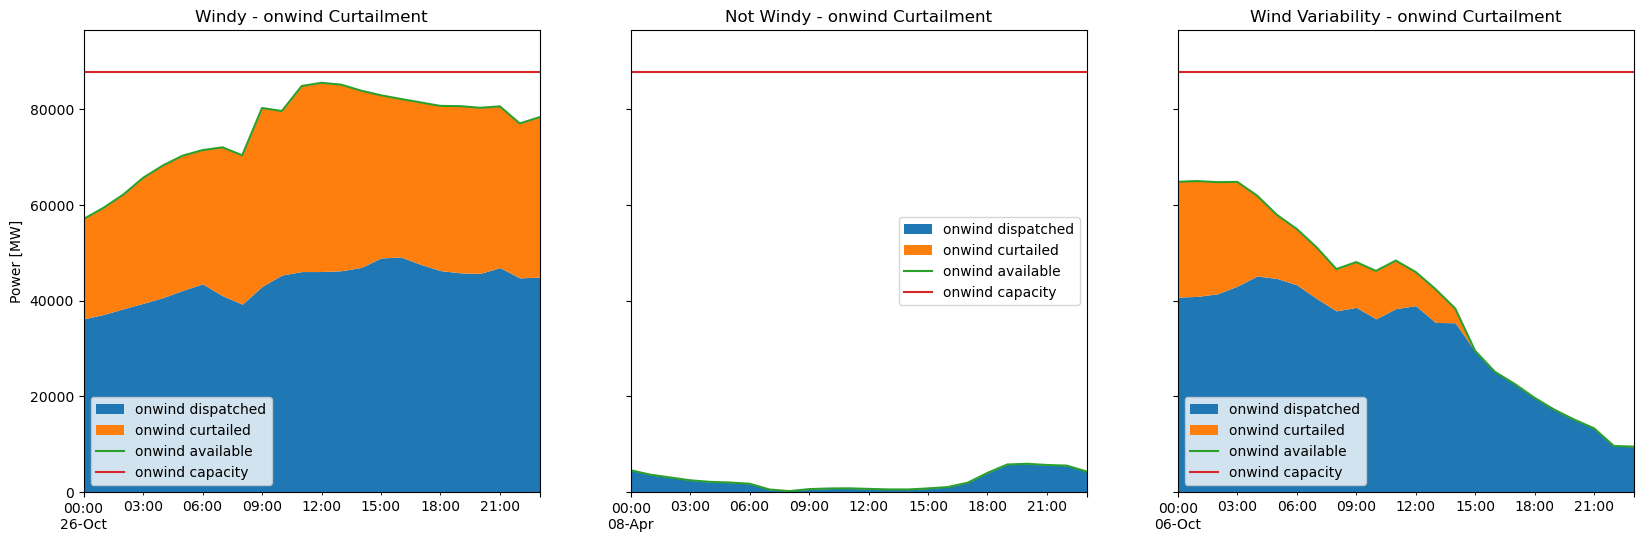

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

plot_curtailment(n1, "onwind", axes[0])
plot_curtailment(n2, "onwind", axes[1])
plot_curtailment(n3, "onwind", axes[2])

save_fig(fig, "05_onwind_curtailment.png")

### 4.2 Generation and Capacity Comparison

##### Power Dispatch by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/06_power_dispatch.png


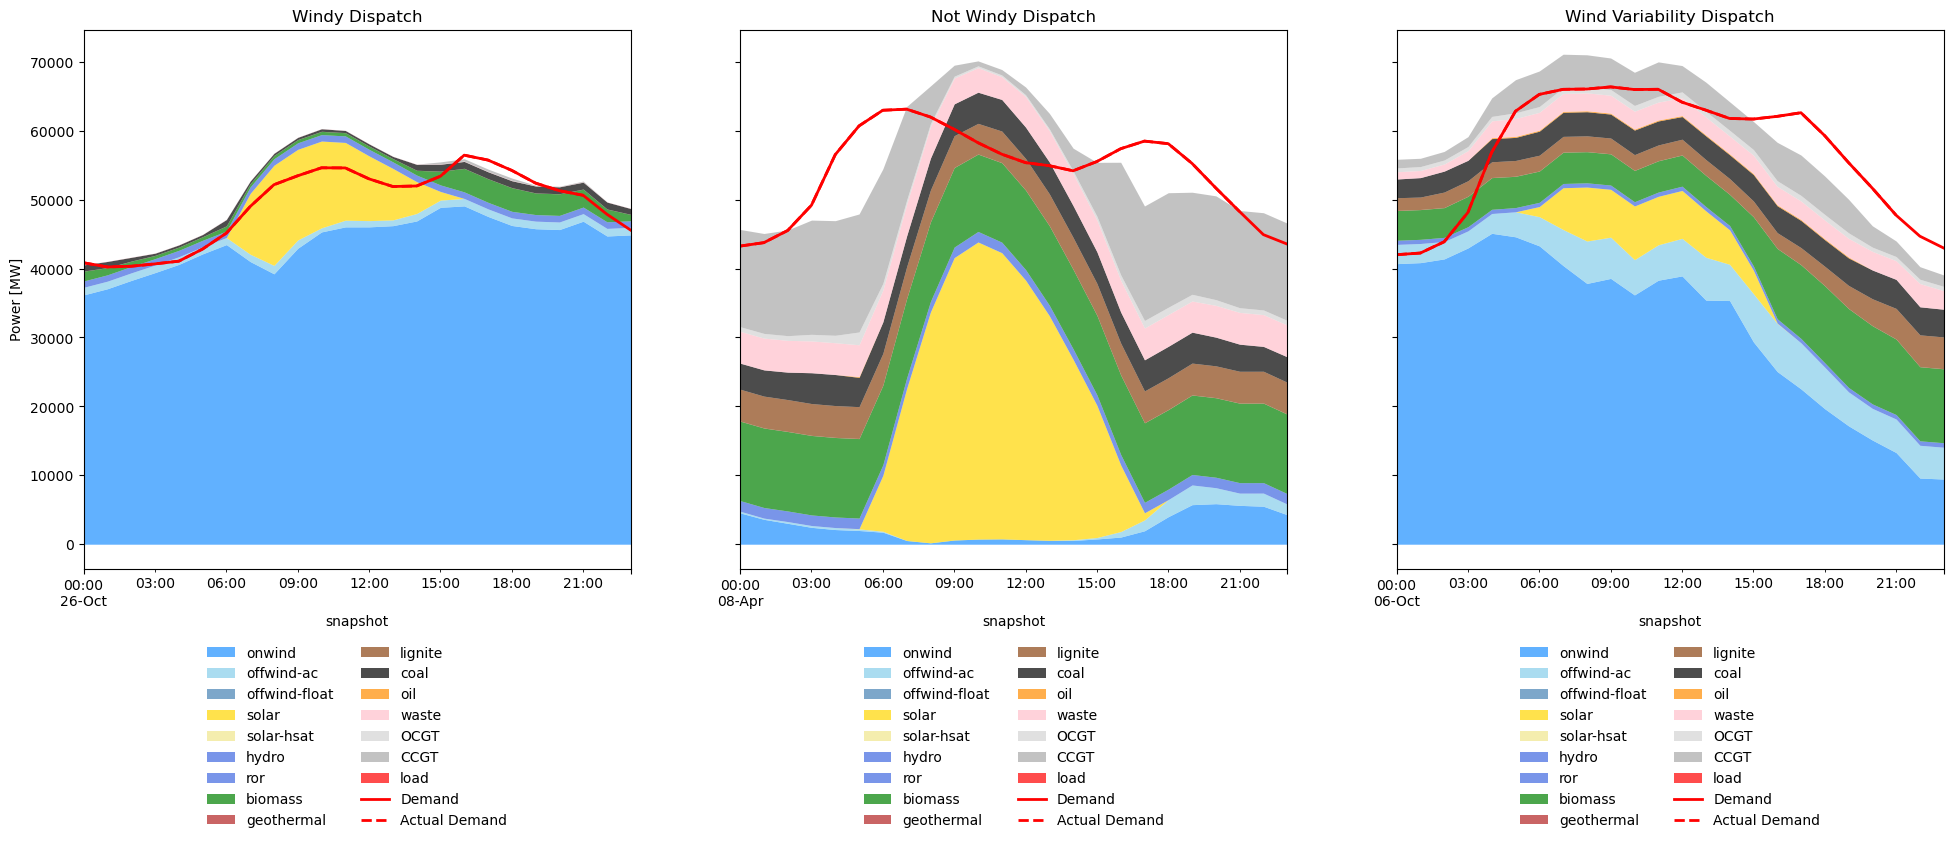

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

# --- Define Colors and Order ---
colors = {
    # Wind
    "onwind": "dodgerblue",
    "offwind-ac": "skyblue",
    "offwind-float": "steelblue",
    # Solar
    "solar": "gold",
    "solar-hsat": "khaki",
    # Hydro
    "hydro": "royalblue",
    "ror": "royalblue",
    # Fossil Fuels
    "lignite": "saddlebrown",
    "coal": "black",
    "oil": "darkorange",
    "OCGT": "lightgray",
    "CCGT": "darkgray",
    # Other
    "biomass": "green",
    "waste": "pink",
    "geothermal": "firebrick",
    "load": "red"
}

cols = [
    # Renewables
    "onwind", "offwind-ac", "offwind-float", 
    "solar", "solar-hsat",
    "hydro", "ror",
    "biomass", "geothermal",
    # Conventional
    "lignite", "coal", "oil", "waste",
    "OCGT", "CCGT",
    # Storage
    "load"
]

# --- Helper function for plotting ---
def plot_dispatch(n, ax, title):
    p_by_carrier = n.generators_t.p.T.groupby(n.generators.carrier).sum().T

    # Add battery discharge as another stacked supply source on the electricity side
    battery_discharge_dispatch = pd.Series(0.0, index=n.snapshots)
    if not n.links.empty and "battery discharger" in set(n.links.carrier):
        battery_discharge_dispatch = -n.links_t.p1.loc[:, n.links.carrier == "battery discharger"].sum(axis=1)

    p_by_carrier["battery discharge"] = battery_discharge_dispatch

    # Reorder and fill missing columns
    p_by_carrier = p_by_carrier.reindex(columns=cols).fillna(0)

    # Get colors in the correct order
    c = [colors.get(col, "gray") for col in p_by_carrier.columns]

    p_by_carrier.plot(kind="area", ax=ax, lw=0, title=title, color=c, alpha=0.7)

    # Add demand curve
    demand = n.loads_t.p_set.sum(axis=1)
    demand.plot(ax=ax, color="red", lw=2, label="Demand")

    scenario_title = n.name

    real_data = pd.read_csv(f"/home/lucakristin/Desktop/my_pypsa/actual_electricity_data/combined_{scenario_title.replace(' ', '_').lower()}.csv", index_col=0, parse_dates=True)
    demand_real = real_data["grid load"]
    # Use simulation snapshots as index for real data to align with simulation time axis
    demand_real = pd.Series(demand_real.values, index=n.snapshots, name="Actual Demand")
    # Shift real data by two hours
    demand_real = demand_real.shift(-2)
    demand_real.plot(ax=ax, color="red",  linestyle="--", lw=2, label="Actual Demand")

    ax.set_ylabel("Power [MW]")
    ax.legend(ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False)

# --- Plotting ---
plot_dispatch(n1, axes[0], "Windy Dispatch")
plot_dispatch(n2, axes[1], "Not Windy Dispatch")
plot_dispatch(n3, axes[2], "Wind Variability Dispatch")

save_fig(fig, "06_power_dispatch.png")

##### Total Energy Production by Carrier

Saved figure: /home/lucakristin/Desktop/my_pypsa/pypsa-eur/analysis/germany_scenario2_/07_energy_production.png

=== Energy Production Summary ===
                   Windy      Not Windy  Wind Variability
carrier                                                  
onwind      1.050758e+06   58894.741658     761402.774395
biomass     3.324117e+04  276475.303426     161663.228621
solar       8.312541e+04  315627.107685      59265.238970
CCGT        1.537064e+03  269353.702355      88709.968234
coal        1.609586e+04  103973.294233      85400.880503
lignite     1.147775e-02  110546.317531      64016.327443
waste       9.517420e+02  107150.512602      57853.018065
offwind-ac  2.527040e+04   17195.480588     116303.153571
ror         2.268130e+04   36724.863039      15010.541003
OCGT        7.183457e-02   16998.561058      17812.179239
oil         2.812344e-02     119.188410       2275.761856
geothermal  3.933408e+02     419.104475        393.411319




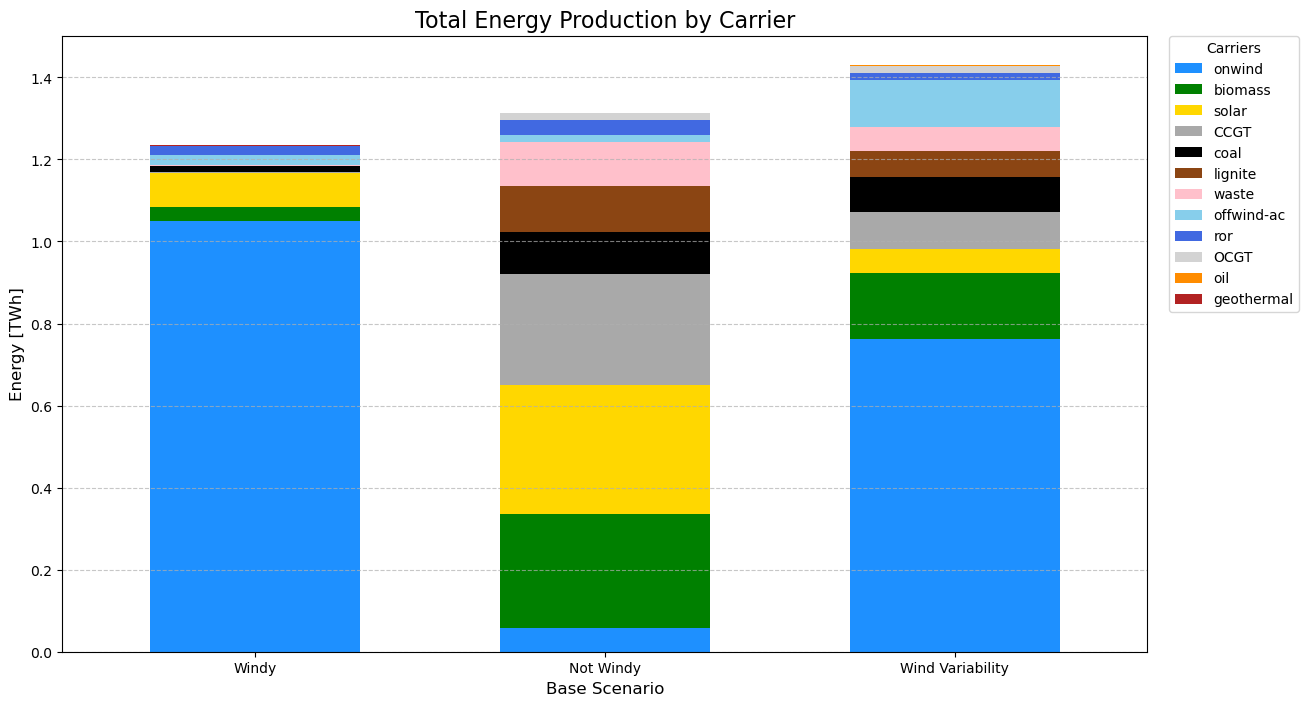

In [50]:
# --- Calculate energy production for each scenario ---
p_by_carrier_n1 = n1.generators_t.p.sum().groupby(n1.generators.carrier).sum()
p_by_carrier_n2 = n2.generators_t.p.sum().groupby(n2.generators.carrier).sum()
p_by_carrier_n3 = n3.generators_t.p.sum().groupby(n3.generators.carrier).sum()

# --- Create a DataFrame for plotting ---
energy_df = pd.DataFrame({
    "Windy": p_by_carrier_n1,
    "Not Windy": p_by_carrier_n2,
    "Wind Variability": p_by_carrier_n3
}).fillna(0)

# Filter out carriers with negligible energy
energy_df = energy_df[energy_df.sum(axis=1) > 0.1]

# --- Sort carriers by total energy production (descending) ---
energy_df = energy_df.loc[energy_df.sum(axis=1).sort_values(ascending=False).index]

# Get colors for the carriers that are present
bar_colors = [colors.get(carrier, "grey") for carrier in energy_df.index]

# --- Plotting ---
fig, ax = plt.subplots(figsize=(14, 8))

# Plot stacked bar chart
(energy_df.T / 1e6).plot(kind="bar", stacked=True, ax=ax, color=bar_colors, width=0.6)

# --- Formatting ---
ax.set_title("Total Energy Production by Carrier", fontsize=16)
ax.set_ylabel("Energy [TWh]", fontsize=12)
ax.set_xlabel("Base Scenario", fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# --- Legend ---
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles, 
    labels, 
    title="Carriers",
    bbox_to_anchor=(1.02, 1), 
    loc='upper left', 
    borderaxespad=0.
)

save_fig(fig, "07_energy_production.png")

# Log energy production summary
log_print("\n=== Energy Production Summary ===")
log_print(energy_df.to_string())
log_print("\n")

In [51]:
def calculate_emissions(n):
    emission_factors = n.c.carriers.static.co2_emissions
    emitting_generators = n.c.generators.static[
        n.c.generators.static.carrier.map(emission_factors).fillna(0) != 0
    ]
    generator_p = n.c.generators.dynamic.p.loc[:, emitting_generators.index]
    generator_efficiency = n.c.generators._as_dynamic("efficiency").loc[:, emitting_generators.index]
    snapshot_weightings = n.snapshot_weightings.generators.reindex(generator_p.index)
    emission_factors_per_generator = emitting_generators.carrier.map(emission_factors)
    co2_emissions = (
        generator_p.multiply(snapshot_weightings, axis=0)
        .multiply(emission_factors_per_generator, axis=1)
        .divide(generator_efficiency)
        .sum()
        .sum()
    )
    return co2_emissions

log_print("\n=== CO2 Emissions Summary ===")
for n in networks.values():
    log_print(f"Total CO2 emissions at the {n.name} day: {calculate_emissions(n):.2f} kg CO2")
log_print("\n")


=== CO2 Emissions Summary ===
Total CO2 emissions at the Windy day: 13947.03 kg CO2
Total CO2 emissions at the Not Windy day: 418628.48 kg CO2
Total CO2 emissions at the Wind Variability day: 243557.93 kg CO2




### Statistics

In [52]:
log_print("\n=== Network Statistics ===")
for n in networks.values():
    log_print(f"\nNetwork: {n.name}")
    log_print(n.statistics().to_string())
    log_print("\n")

log_print("\n=== Analysis Complete ===")
log_print(f"All results saved to: {analysis_dir}")


=== Network Statistics ===

Network: Windy
                                  Optimal Capacity  Installed Capacity        Supply    Withdrawal  Energy Balance  Transmission  Capacity Factor   Curtailment  Capital Expenditure  Operational Expenditure       Revenue  Market Value
Generator   Combined-Cycle Gas        1.846575e+04        1.846575e+04  1.537064e+03  0.000000e+00    1.537064e+03       0.00000     3.468278e-03  4.416409e+05         6.396315e+06              73320.96342  7.533317e+04     49.011069
            Offshore Wind (AC)        2.308219e+04        2.308219e+04  2.527040e+04  0.000000e+00    2.527040e+04       0.00000     4.561670e-02  4.631335e+05         1.883735e+07                862.13146  8.749345e+02      0.034623
            Onshore Wind              8.771231e+04        8.771231e+04  1.050758e+06  0.000000e+00    1.050758e+06       0.00000     4.991499e-01  7.682386e+05         2.855333e+07              36431.07101  2.807782e+06      2.672148
            Open-Cyc